# クラスタリング
クラスタリング問題を最適化問題として扱います。

## 概要
クラスタリングとは、異なる値を持つ多数のデータをいくつかのクラスタに分類することです。
似た特徴を持つデータを同じクラスタに分類することでグループ化でき、マーケティングなどの用途に利用されます。

## 例

### QAOAによるクラスタリング
4つの点(ノード)を2つのクラスタに分割する場合を考えます。

まず、2つのクラスタを表す量子ビットの組 $q_0,q_1,q_2,q_3$ と $q_4,q_5,q_6,q_7$ を用意します。
$q_0$ と $q_4$、$q_1$ と $q_5$、$q_2$ と $q_6$、$q_3$ と $q_7$ はそれぞれ同じノードを表しており、ノードが属するクラスタを表す量子ビットは値1を、属さないクラスタを表す量子ビットは値0を取ります。
例えば、ノード0がクラスタ1に属する場合は $q_0 = 1, q_4 = 0$ となり、ノード0がクラスタ2に属する場合は $q_0 = 0, q_4 = 1$ となります。
したがって、必要な量子ビット数は $4\times2=8$ です。

同じクラスタに属するノード間の距離の合計が小さくなるようにコスト関数を設定します。

$$
Cost = \sum d_{ij} q_i q_j\ \ \ \ (q_i \in \{0, 1\})
$$

$d_{ij}$ はノード $i$ と $j$ の間の距離です。

制約は、同じノードを表す量子ビットのうちどれか1つだけが1になり、残りが0になるように設定します。
$$
Constraint = \sum(\sum_{i}^n q_i - 1)^2
$$

しかし、QAOAでは、この場合、XYミキサー回路を実装することで制約項を取り除くことができます。

$XY$ミキサーは、以下の行列 $H_{XY}$ による時間発展を行います。

$$
H_{XY} = (X_0 X_1 + Y_0 Y_1)/2 = \begin{pmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0
\end{pmatrix}
$$

この時間発展は、以下の2量子ビットゲート $U_{XY}$ で表されます。

$$
U_{XY} = e^{-i\theta H_{XY}} = \begin{pmatrix}
0 & 0 & 0 & 0 \\
0 & \cos\theta & -i\sin\theta & 0 \\
0 & -i\sin\theta & \cos\theta & 0 \\
0 & 0 & 0 & 0
\end{pmatrix}
$$

振幅は $\lvert 01\rangle$ と $\lvert 10\rangle$ の2状態の間で交換されます。
したがって、初期状態として $\lvert 01\rangle$ と $\lvert 10\rangle$ のエンタングル状態を用意して $U_{XY}$ を適用すれば、制約条件を満たさない $\lvert 00\rangle$ と $\lvert 11\rangle$ の振幅をゼロに保ったまま、$\lvert 01\rangle$ と $\lvert 10\rangle$ の2状態の間だけを探索することができます。
これは、制約を満たさない解が探索されないため、QUBOから制約を取り除くことができることを意味します。

したがって、QUBO行列はコスト関数のみで構成されます。
ネットワーク図で表すと、制約項を含めていた場合よりも辺の数が少なくなっていることが分かります。
これは、相互作用が少なくなり問題がよりシンプルになることを意味します。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from blueqat import Circuit
from blueqat.utils import Vqe, QaoaAnsatz
from blueqat.utils import X,Y,Z
from blueqat.utils import qubo_bit as q

まず、データを作成します。今回は、上記の例と同じ大きさで、4つのノードを2つのクラスタに分割します。(以下で使用する `QaoaAnsatz`/`Vqe` オプティマイザは $2^{n\_qubits}$ 個の全状態をシミュレートするため、以前のバージョンのこのノートブックで使われていたような、正確にシミュレートするには大きすぎるランダムグラフではなく、小さなグラフを使用します。)

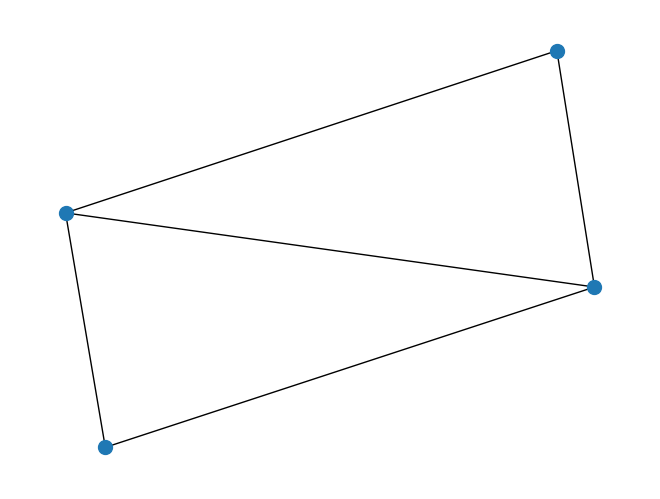

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

n = 4
m = 5
seed = 15

options = {'node_size': 100}

G = nx.gnm_random_graph(n, m, seed = seed)
nx.draw(G, **options)

次に、QUBO行列を作成します。

まず、ノード間の接続に基づくコスト関数を表すQUBO行列を用意します。

/Users/yuichirominato/blueqatSDK/.claude/worktrees/determined-mahavira-bf713e/blueqat/utils.py:399: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  total_matrix = torch.sparse_coo_tensor(torch.empty((2, 0), dtype=torch.int64, device=device), torch.empty(0, dtype=torch.complex128, device=device), (dim, dim))


sample:01101001


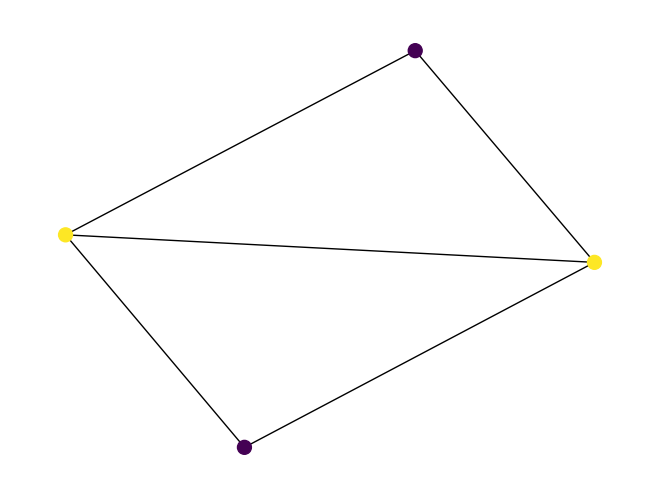

In [3]:
hamiltonian = sum(q(e[0])*q(e[1]) + q(e[0]+n)*q(e[1]+n)  for e in G.edges)
step = 2

#mixer and init state
mixer = 0.0
init = Circuit()
for i in range(n):
    mixer += 0.5*X[i]*X[i+n] + 0.5*Y[i]*Y[i+n]
    init.h[i].cx[i,i+n].x[i]

# `step` is now the number of variational QAOA layers optimized by gradient
# descent (previously a cheap fixed Trotter-schedule granularity), and
# QaoaAnsatz/Vqe build the full Hamiltonian over 2**n_qubits states, so
# step=2 with max_iter=100 keeps this well under a few seconds for our
# 8-qubit problem.
ansatz = QaoaAnsatz(hamiltonian, step, init, mixer)
result = Vqe(ansatz).run(max_iter=100)
b = result.circuit.run(shots=10)
sample = b.most_common(1)[0][0]
print("sample:"+ str(sample))

nx.draw(G, **options, node_color=[int(s) for s in list(sample[:n])])